In [13]:
import pandas as pd
import os
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import shap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

In [14]:
BASE_PATH = '/kaggle/input/datasets/andreeabrleanu/yahoo-dataset'

dfs = {}

for file in [
    'train.csv',
    'ham_test.csv',
    'ham_validation.csv',
    'scam_test.csv',
    'scam_validation.csv'
]:
    path = os.path.join(BASE_PATH, file)
    dfs[file] = pd.read_csv(path)

train_df = dfs['train.csv']
ham_test_df = dfs['ham_test.csv']
ham_validation_df = dfs['ham_validation.csv']
scam_test_df = dfs['scam_test.csv']
scam_validation_df = dfs['scam_validation.csv']


zero_var_cols = []

for col in train_df.columns:
    if train_df[col].nunique() <= 1:
        zero_var_cols.append(col)

all_dfs = [
    train_df,
    ham_test_df,
    ham_validation_df,
    scam_test_df,
    scam_validation_df
]

for col in zero_var_cols:
    for df in all_dfs:
        df.drop(columns=[col], inplace=True)

print(f"Removed columns: {zero_var_cols}")


cols_to_impute = []
for df in all_dfs:
    for col in df.columns:
        if df[col].isna().any():
            if col not in cols_to_impute:
                cols_to_impute.append(col) 

print(f"Columns with NaN in any dataset: {cols_to_impute}")

if len(cols_to_impute) > 0:
    imputer = SimpleImputer(strategy="median")
    train_df[cols_to_impute] = imputer.fit_transform(train_df[cols_to_impute])
    for df in all_dfs:
        df[cols_to_impute] = imputer.transform(df[cols_to_impute])

    print("Imputation done.\n")


scaler = StandardScaler()

feature_cols = train_df.columns

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

for df in dfs.values():
    if df is not train_df:
        df[feature_cols] = scaler.transform(df[feature_cols])

X_train = train_df.to_numpy(dtype=float)

X_test_legit = ham_test_df.to_numpy(dtype=float)
X_val_legit = ham_validation_df.to_numpy(dtype=float)

X_test_scam = scam_test_df.to_numpy(dtype=float)
X_val_scam = scam_validation_df.to_numpy(dtype=float)


features = list(train_df.columns)
no_features    = X_train.shape[1]


print(f"Training (legit): {X_train.shape}\n")

print(f"Validation scam: {X_val_scam.shape}")
print(f"Validation legit: {X_val_legit.shape}\n")

print(f"Test scam: {X_test_scam.shape}")
print(f"Test legit: {X_test_legit.shape}\n")


print(f"Features ({no_features}): {features}")

Removed columns: ['spf_result']
Columns with NaN in any dataset: ['lev_from_dkim', 'lev_helo_messageid', 'asn_avg_rep', 'lev_from_returnpath', 'lev_returnpath_helo']
Imputation done.

Training (legit): (2066, 17)

Validation scam: (154, 17)
Validation legit: (258, 17)

Test scam: (154, 17)
Test legit: (259, 17)

Features (17): ['dkim_result', 'dkim_algorithm', 'dmarc_result', 'dmarc_policy', 'lev_from_returnpath', 'lev_from_dkim', 'lev_returnpath_helo', 'lev_helo_messageid', 'reply_to_present', 'hop_count', 'total_delay_log', 'asn_in_nerd', 'asn_avg_rep', 'ptr_exists', 'ptr_matches_helo', 'helo_domain_resolves', 'from_domain_has_mx']


In [15]:
X_val = np.vstack([
    X_val_legit,
    X_val_scam
])

y_val = np.concatenate([
    np.zeros(X_val_legit.shape[0]),
    np.ones(X_val_scam.shape[0])
])


X_test = np.vstack([
    X_test_legit,
    X_test_scam
])

y_test = np.concatenate([
    np.zeros(X_test_legit.shape[0]),
    np.ones(X_test_scam.shape[0])
])


# X_val_legit = X_val[y_val == 0]
# X_val_scam  = X_val[y_val == 1]

# X_test_legit = X_test[y_test == 0]
# X_test_scam  = X_test[y_test == 1]

print("Data split:\n")

print(f"Train (legit only): {X_train.shape[0]} emails")
print(f"Validation set: {X_val.shape[0]} (legit: {(y_val == 0).sum()}, scam: {(y_val == 1).sum()})")
print(f"Test set: {X_test.shape[0]} (legit: {(y_test == 0).sum()}, scam: {(y_test == 1).sum()})\n")

Data split:

Train (legit only): 2066 emails
Validation set: 412 (legit: 258, scam: 154)
Test set: 413 (legit: 259, scam: 154)



In [16]:
EULER_CONSTANT = 0.5772156649

class ExNode:
    def __init__(self, size):
        self.size = size

class InNode:
    def __init__(self, left, right, n, p):
        self.left = left
        self.right = right
        self.n = n
        self.p = p

def build_itree(X, current_depth, height_limit, rand):
    if current_depth >= height_limit or X.shape[0] <= 1:
        return ExNode(size=X.shape[0])
    n_features = X.shape[1]
    n = rand.standard_normal(n_features)
    p = rand.uniform(X.min(axis=0), X.max(axis=0))
    projections = (X - p) @ n
    left = projections <= 0
    if left.all() or (~left).all():
        return ExNode(size=X.shape[0])
    return InNode(left=build_itree(X[left],  current_depth + 1, height_limit, rand), 
        right=build_itree(X[~left], current_depth + 1, height_limit, rand),
        n=n, p=p
    )

def harmonic(i):
    return np.log(i) + EULER_CONSTANT

def c_factor(n):
    if n <= 1:
        return 0.0
    return 2.0 * harmonic(n - 1) - (2.0 * (n - 1) / n)

def path_length(x, node, current_depth):
    if isinstance(node, ExNode):
        return current_depth + c_factor(node.size)
    if np.dot(x - node.p, node.n) <= 0:
        return path_length(x, node.left, current_depth + 1)
    else:
        return path_length(x, node.right, current_depth + 1)

class ExtendedIsolationForest:
    def __init__(self, n_trees=100, sample_size=256, random_state=42):
        self.n_trees = n_trees
        self.sample_size = sample_size
        self.random_state = random_state

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n_samples, n_features = X.shape
        self.psi = min(self.sample_size, n_samples)
        self.height_limit = int(np.ceil(np.log2(max(self.psi, 2))))
        self.n_features = n_features
        self.c_psi = c_factor(self.psi)
        rand = np.random.default_rng(self.random_state)
        self.trees = []
        for _ in range(self.n_trees):
            idx = rand.choice(n_samples, size=self.psi, replace=False)
            seed = rand.integers(0, 2**31 - 1)
            self.trees.append(build_itree(X[idx], 0, self.height_limit, np.random.default_rng(seed)))
        return self

    def path_lengths(self, X):
        X = np.asarray(X, dtype=float)
        out = np.empty(X.shape[0])
        for i, x in enumerate(X):
            total = sum(path_length(x, t, 0) for t in self.trees)
            out[i] = total / len(self.trees)
        return out

    def anomaly_score(self, X):
        Eh = self.path_lengths(X)
        return np.power(2.0, -Eh / self.c_psi)

    def predict(self, X, threshold):
        return self.anomaly_score(X) > threshold

In [17]:
def f1_optimal_threshold(scores, y_true, n_thresholds=500):
    thresholds = np.linspace(scores.min(), scores.max(), n_thresholds)
    best_f1 = -1
    best_thr = None

    for thr in thresholds:
        preds = (scores > thr).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        fn = ((preds == 0) & (y_true == 1)).sum()
        p  = tp / (tp + fp) if (tp + fp) else 0
        r  = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * p * r / (p + r) if (p + r) else 0
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr, best_f1


t_fixed = 100
sample_sizes = [32, 64, 128, 256]
rows_psi = []

for psi in sample_sizes:
    if psi > X_train.shape[0]:
        continue

    m = ExtendedIsolationForest(n_trees=t_fixed, sample_size=psi, random_state=42)
    m.fit(X_train)
    sc = m.anomaly_score(X_val)

    fpr_vals, tpr_vals, _ = roc_curve(y_val, sc)
    roc_auc = auc(fpr_vals, tpr_vals)

    rows_psi.append(dict(psi=psi, VAL_ROC_AUC=roc_auc))
    print(f"psi = {psi:3d} | ROC-AUC = {roc_auc:.4f}")

df_psi = pd.DataFrame(rows_psi)
best_psi = int(df_psi.loc[df_psi.VAL_ROC_AUC.idxmax(), 'psi'])
print(f"\nBest psi (ROC-AUC): {best_psi}\n")


tree_counts = [50, 75, 100, 150, 200]
rows_t = []

for t_val in tree_counts:
    m = ExtendedIsolationForest(n_trees=t_val, sample_size=best_psi, random_state=42)
    m.fit(X_train)
    sc = m.anomaly_score(X_val)

    fpr_vals, tpr_vals, _ = roc_curve(y_val, sc)
    roc_auc = auc(fpr_vals, tpr_vals)

    rows_t.append(dict(t=t_val, VAL_ROC_AUC=roc_auc))
    print(f"t ={t_val:4d} | ROC-AUC = {roc_auc:.4f}")

df_t = pd.DataFrame(rows_t)
best_t = int(df_t.loc[df_t.VAL_ROC_AUC.idxmax(), 't'])
print(f"\nBest t (ROC-AUC): {best_t}\n")


eif_final = ExtendedIsolationForest(n_trees=best_t, sample_size=best_psi, random_state=42)
eif_final.fit(X_train)
sc_val_final = eif_final.anomaly_score(X_val)

final_threshold, final_f1 = f1_optimal_threshold(sc_val_final, y_val)

print(f"Hyperparameter tuning:")
print(f"psi = {best_psi} | t = {best_t}")
print(f"Threshold: {final_threshold:.6f}")

psi =  32 | ROC-AUC = 0.9825
psi =  64 | ROC-AUC = 0.9847
psi = 128 | ROC-AUC = 0.9851
psi = 256 | ROC-AUC = 0.9881

Best psi (ROC-AUC): 256

t =  50 | ROC-AUC = 0.9875
t =  75 | ROC-AUC = 0.9876
t = 100 | ROC-AUC = 0.9881
t = 150 | ROC-AUC = 0.9880
t = 200 | ROC-AUC = 0.9880

Best t (ROC-AUC): 100

Hyperparameter tuning:
psi = 256 | t = 100
Threshold: 0.557295


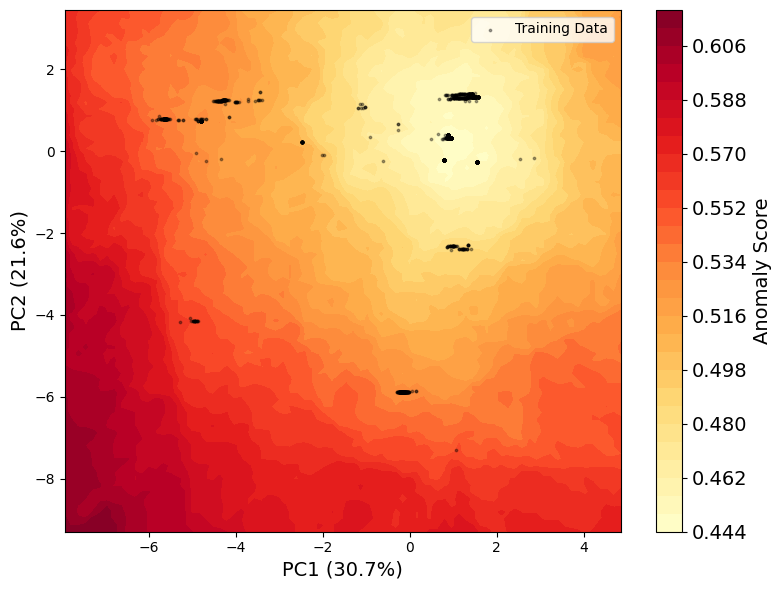

In [18]:
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train)
X2_train = pca.transform(X_train)

pad = 2.0
xx, yy = np.meshgrid(
    np.linspace(X2_train[:, 0].min() - pad, X2_train[:, 0].max() + pad, 80),
    np.linspace(X2_train[:, 1].min() - pad, X2_train[:, 1].max() + pad, 80)
)

grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_nd = pca.inverse_transform(grid_2d)
Z = eif_final.anomaly_score(grid_nd).reshape(xx.shape)

ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.contourf(xx, yy, Z, levels=30, cmap='YlOrRd')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Anomaly Score', fontsize=14)
cbar.ax.tick_params(labelsize=14)

ax.scatter(
    X2_train[:, 0], X2_train[:, 1],
    c='black', s=3, alpha=0.35, label='Training Data'
)

ax.legend(fontsize=14)

ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=14)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=14)
# ax.set_title('EIF Heat Map', fontsize=18, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

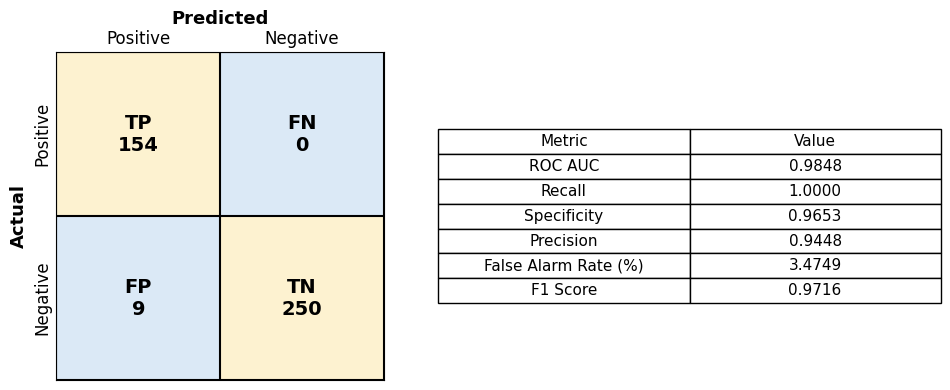

In [19]:
scores_test = eif_final.anomaly_score(X_test) 
scores_legit = scores_test[y_test == 0] 
scores_scam = scores_test[y_test == 1] 
scores_train = eif_final.anomaly_score(X_train) 

pl_final_legit = eif_final.path_lengths(X_test_legit) 
pl_final_spam = eif_final.path_lengths(X_test_scam) 
pl_train_final = eif_final.path_lengths(X_train) 
preds_final = (scores_test > final_threshold).astype(int) 

tp = ((preds_final==1)&(y_test==1)).sum() 
fp = ((preds_final==1)&(y_test==0)).sum() 
tn = ((preds_final==0)&(y_test==0)).sum() 
fn = ((preds_final==0)&(y_test==1)).sum() 

roc_auc = roc_auc_score(y_test, scores_test) 
recall = tp/(tp+fn) if (tp+fn) else 0 
specificity = tn/(tn+fp) if (tn+fp) else 0 
far = fp/(fp+tn) if (fp+tn) else 0 
precision = tp/(tp+fp) if (tp+fp) else 0 
f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0

fig, (ax1, ax2) = plt.subplots( 1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.2, 1]} )
cmap = mcolors.ListedColormap(['#dbe9f6', '#fdf2d0'])

ax1.imshow([[1, 0], [0, 1]], cmap=cmap, aspect='equal')

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])

ax1.set_xticklabels(['Positive', 'Negative'], fontsize=12)
ax1.set_yticklabels(['Positive', 'Negative'], fontsize=12, rotation=90, va="center")

ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=13, fontweight='bold')

labels = [["TP", "FN"],
          ["FP", "TN"]]

cm = np.array([[tp, fn],
               [fp, tn]])

for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{labels[i][j]}\n{cm[i, j]}",
                 ha="center", va="center",
                 fontsize=14, fontweight='bold')

ax1.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax1.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax1.grid(which='minor', color='black', linewidth=1.5)
ax1.tick_params(which='both', length=0)


df_metrics = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "Recall",
        "Specificity",
        "Precision",
        "False Alarm Rate (%)",
        "F1 Score"
    ],
    "Value": [
        roc_auc,
        recall,
        specificity,
        precision,
        far * 100,
        f1
    ]
})

df_metrics["Value"] = df_metrics["Value"].map(lambda x: f"{x:.4f}")

ax2.axis("off")

table = ax2.table(
    cellText=df_metrics.values,
    colLabels=df_metrics.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.4)

plt.tight_layout()
plt.show()

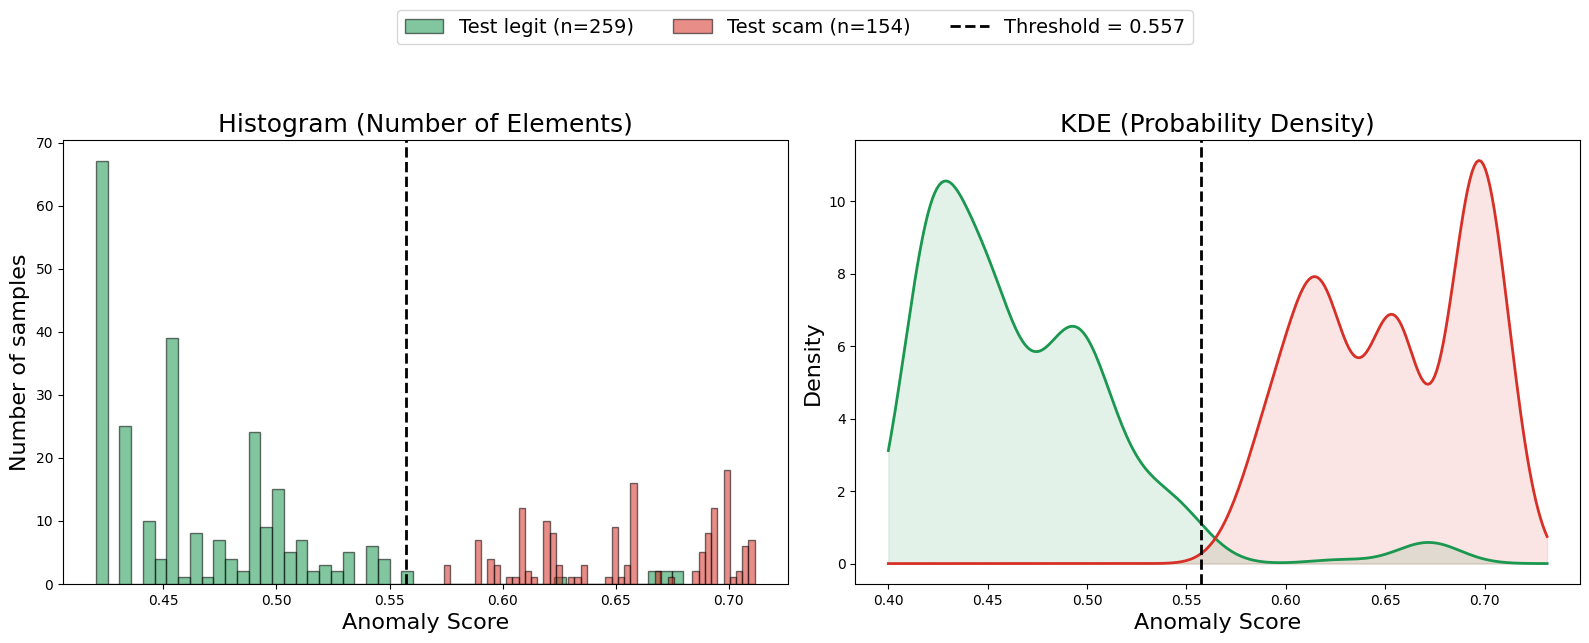

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, mode in [(axes[0], 'hist'), (axes[1], 'kde')]:

    if mode == 'hist':

        ax.hist(
            scores_legit,
            bins=50,
            alpha=.55,
            density=False,
            color='#1a9850',
            edgecolor='k',
            lw=.3,
            label=f'Test legit (n={len(scores_legit)})'
        )

        ax.hist(
            scores_scam,
            bins=50,
            alpha=.55,
            density=False,
            color='#d73027',
            edgecolor='k',
            lw=.3,
            label=f'Test scam (n={len(scores_scam)})'
        )

        ax.set_title('Histogram (Number of Elements)', fontsize=18)
        ax.set_ylabel('Number of samples', fontsize=16)

    else:

        lo = min(scores_train.min(),
                 scores_legit.min(),
                 scores_scam.min()) - .02

        hi = max(scores_train.max(),
                 scores_legit.max(),
                 scores_scam.max()) + .02

        xs = np.linspace(lo, hi, 300)

        for d, lb, c in [
            # (scores_train, 'Train legit', '#2166ac'),
            (scores_legit, 'Test legit', '#1a9850'),
            (scores_scam,  'Test scam',  '#d73027')
        ]:
            k = gaussian_kde(d, bw_method=.3)
            ax.plot(xs, k(xs), lw=2, c=c, label=lb)
            ax.fill_between(xs, k(xs), alpha=.12, color=c)

        ax.set_title('KDE (Probability Density)', fontsize=18)
        ax.set_ylabel('Density', fontsize=16)
    ax.axvline(
        final_threshold,
        color='k',
        ls='--',
        lw=2,
        label=f'Threshold = {final_threshold:.3f}'
    )

    ax.set_xlabel('Anomaly Score', fontsize=16)
    # ax.legend(fontsize=14)
    # ax.grid(True, alpha=.3)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=3,
    fontsize=14,
    bbox_to_anchor=(0.5, 1.08)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.tight_layout()
plt.show()

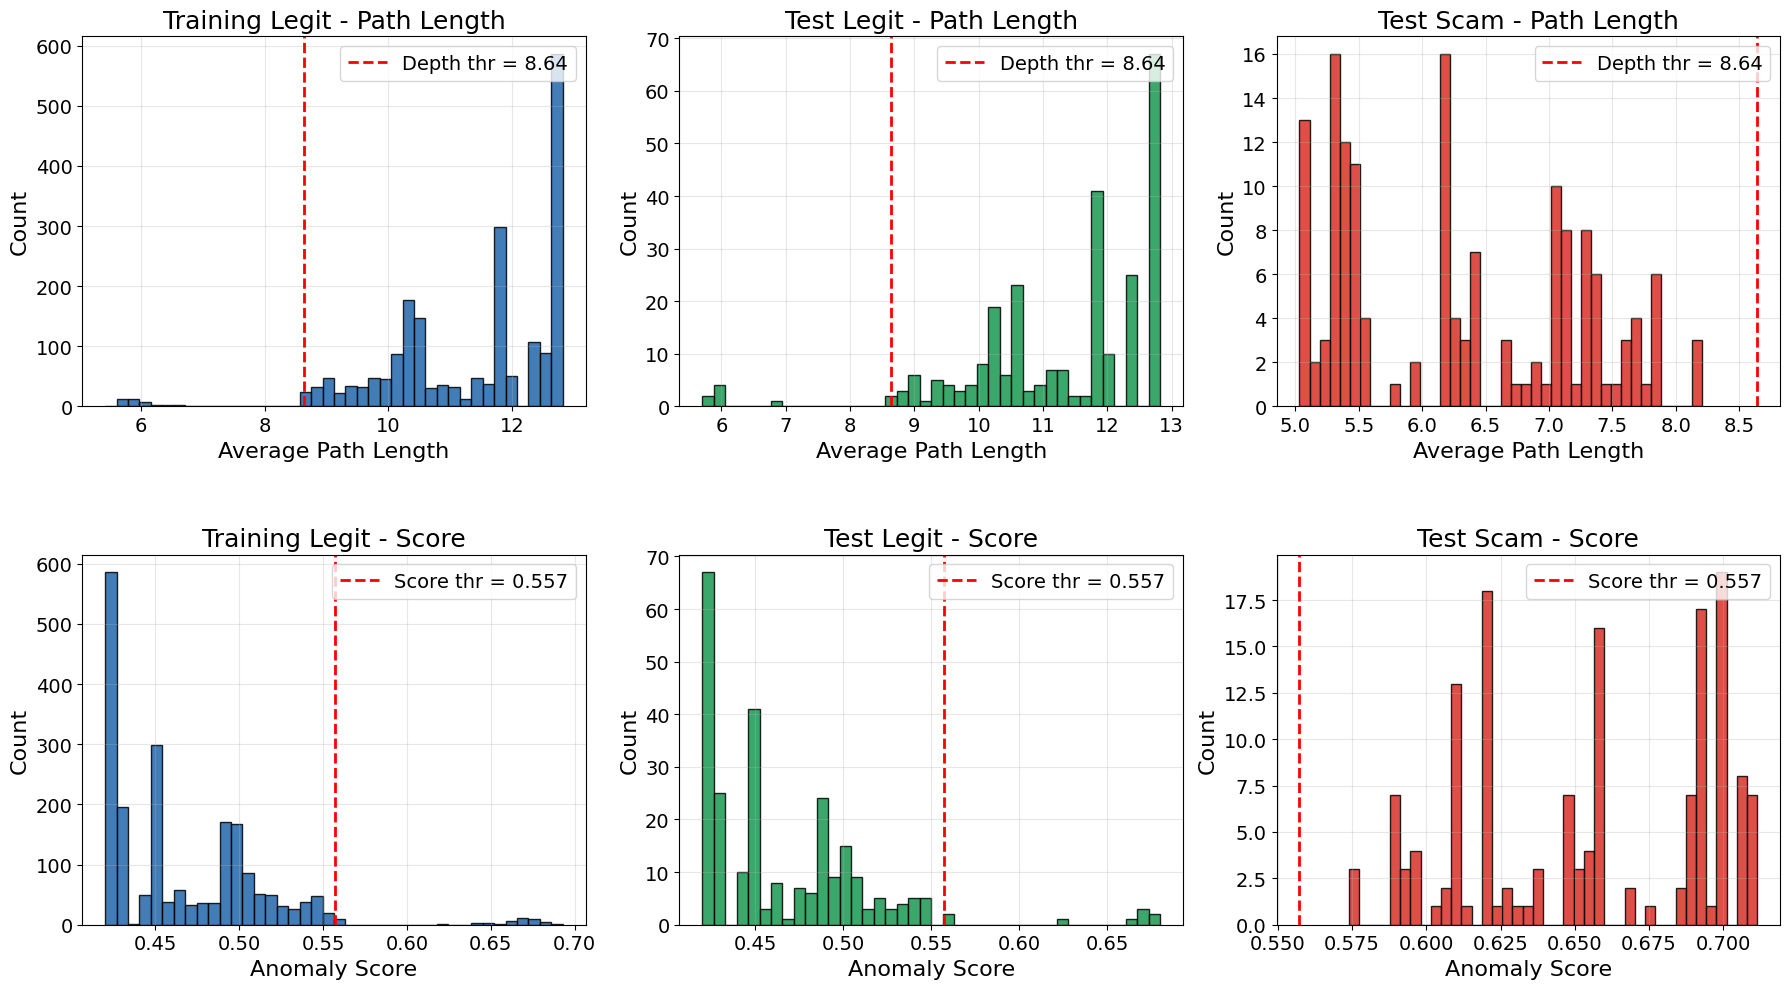

In [21]:
thr_depth = -eif_final.c_psi * np.log2(final_threshold)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (pl_train_final, scores_train, 'Training Legit', '#2166ac'),
    (pl_final_legit, scores_legit, 'Test Legit', '#1a9850'),
    (pl_final_spam, scores_scam, 'Test Scam', '#d73027')
]

for col, (pl, sc, lbl, clr) in enumerate(datasets):

    ax = axes[0, col]

    ax.hist(pl, bins=40, color=clr, alpha=.85,
            edgecolor='k', lw=.3)

    ax.axvline(
        thr_depth,
        color='red',
        ls='--',
        lw=2,
        label=f'Depth thr = {thr_depth:.2f}'
    )

    ax.set_title(f'{lbl} - Path Length', fontsize=18)
    ax.set_xlabel('Average Path Length', fontsize=16)
    ax.set_ylabel('Count', fontsize=16)

    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=.3)

    ax = axes[1, col]

    ax.hist(sc, bins=40, color=clr, alpha=.85,
            edgecolor='k', lw=.3)

    ax.axvline(
        final_threshold,
        color='red',
        ls='--',
        lw=2,
        label=f'Score thr = {final_threshold:.3f}'
    )

    ax.set_title(f'{lbl} - Score', fontsize=18)
    ax.set_xlabel('Anomaly Score', fontsize=16)
    ax.set_ylabel('Count', fontsize=16)

    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=.3)

# plt.suptitle('Path Lengths and Scores (Test Set)',
#              fontsize=14, y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

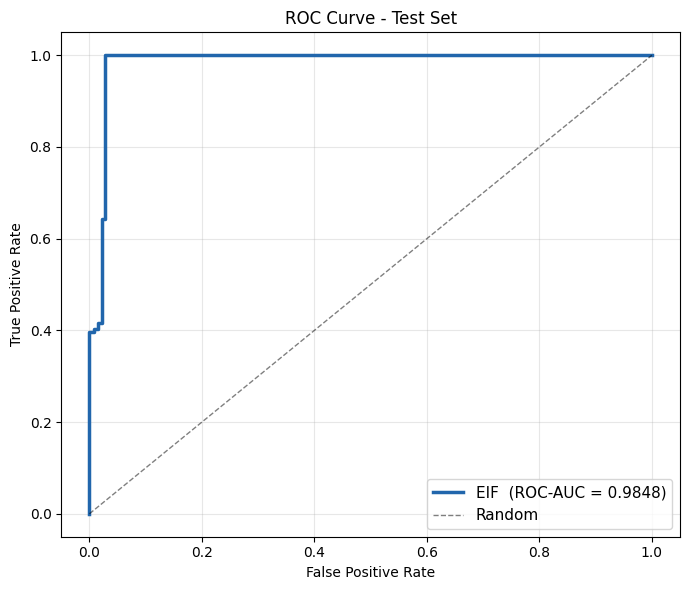

In [22]:
fpr, tpr, _ = roc_curve(y_test, scores_test)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2.5, color='#2166ac', label=f'EIF  (ROC-AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=.5, label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve - Test Set')
ax.legend(fontsize=11); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

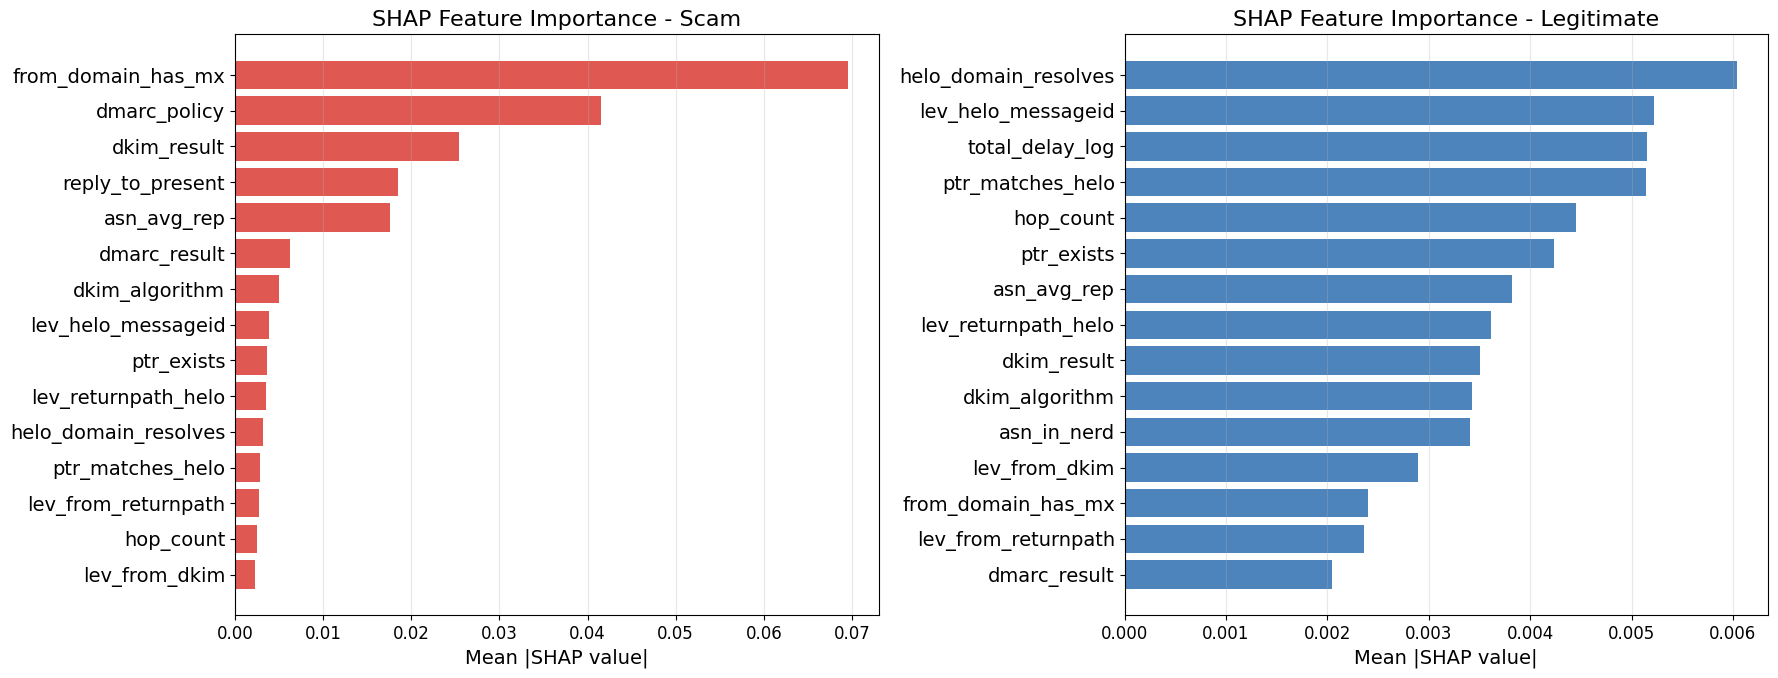

In [23]:
bg_idx = np.random.default_rng(42).choice(X_train.shape[0], 50, replace=False)
explainer = shap.KernelExplainer(eif_final.anomaly_score, X_train[bg_idx])
n_ex = min(50, len(X_test_scam), len(X_test_legit))
spam_idx  = np.random.default_rng(42).choice(len(X_test_scam), n_ex, replace=False)
legit_idx = np.random.default_rng(42).choice(len(X_test_legit), n_ex, replace=False)
sv_spam  = explainer.shap_values(X_test_scam[spam_idx],  nsamples=80, silent=True)
sv_legit = explainer.shap_values(X_test_legit[legit_idx], nsamples=80, silent=True)

plt.rcParams.update({
    'font.size': 14,          # font general
    'axes.titlesize': 16,     # titluri axe
    'axes.labelsize': 14,     # xlabel/ylabel
    'xtick.labelsize': 12,    # tick x
    'ytick.labelsize': 12,    # tick y
    'legend.fontsize': 12
})


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, sv, title, clr in [
    (axes[0], sv_spam, 'Scam', '#d73027'),
    (axes[1], sv_legit, 'Legitimate', '#2166ac')]:
    mi = np.abs(sv).mean(0)
    si = np.argsort(mi)[::-1][:15]
    ax.barh(range(len(si)), mi[si][::-1], color=clr, alpha=.8)
    ax.set_yticks(range(len(si)))
    ax.set_yticklabels([features[i] for i in si][::-1], fontsize=14)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'SHAP Feature Importance - {title}')
    ax.grid(True, alpha=.3, axis='x')
# plt.suptitle('SHAP Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()